# An empirical analysis of circuit obfuscation with QUIMB

In this notebook, we will perform a few experiments on the obfuscated circuit we previously created in `pyzx_circuit_obfuscation.ipynb`. Please run the latter fully before proceeding : in particular, the files `out/obfuscated_circuit.qasm` and `out/original_circuit.qasm` should exist.

Our study will make use of the [QUIMB](https://quimb.readthedocs.io/en/latest/) library for quantum information using tensor networks.

In [1]:
import quimb.tensor as qtn
import quimb as qu
import cotengra as ctg
import matplotlib.pyplot as plt
import numpy as np

We start by loading the original and obfuscated circuits.

Number of qubits: 10
Original and then obfuscated circuits:


(<Figure size 1616.67x166.667 with 1 Axes>, <Axes: >)

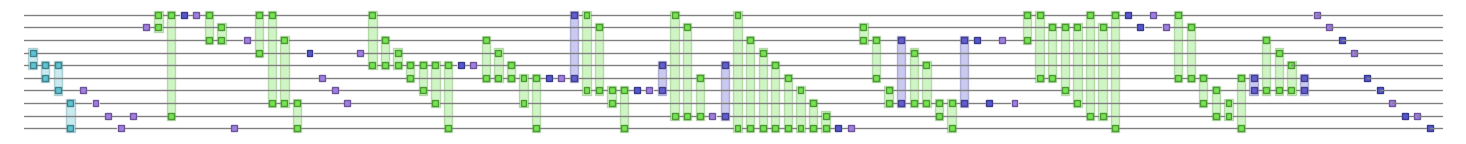

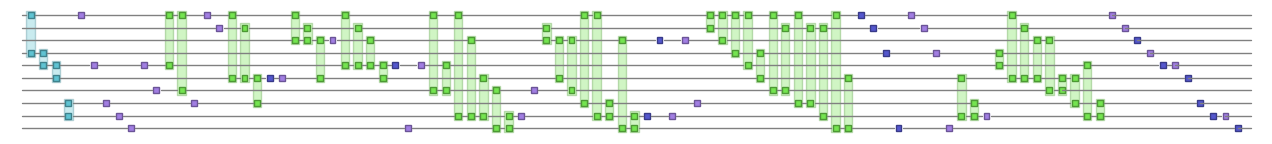

In [2]:
c_original = qtn.Circuit.from_openqasm2_file("../out/original_circuit.qasm")
c_obfuscated = qtn.Circuit.from_openqasm2_file("../out/obfuscated_circuit.qasm")

num_qubits = c_original.N
print(f"Number of qubits: {num_qubits}")

print("Original and then obfuscated circuits:")
c_original.draw()
c_obfuscated.draw()

Then, convert the circuits to tensor networks :

/home/hage/anaconda3/lib/python3.13/site-packages/quimb/tensor/circuit.py:2587: FutureWarning: In future the tensor network returned by ``circ.uni`` will not be transposed as it is currently, to match the expectation from ``U = circ.uni.to_dense()`` behaving like ``U @ psi``. You can retain this behaviour with ``circ.get_uni(transposed=True)``.
  warnings.warn(


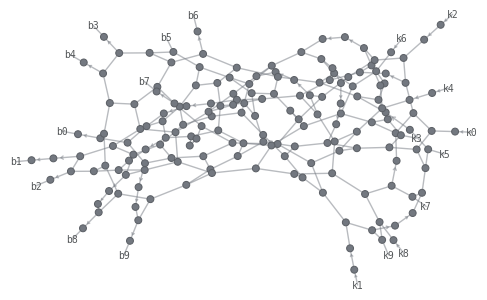

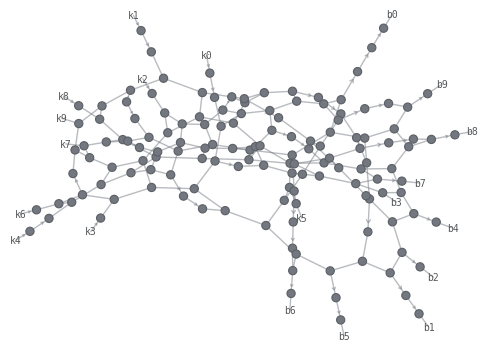

In [3]:
tn_original = c_original.uni
tn_original.draw()

tn_obfuscated = c_obfuscated.uni
tn_obfuscated.draw()

In [4]:
opt = ctg.HyperOptimizer(
    methods=["greedy", "kahypar"],
    max_repeats=32,
    parallel="threads",
    progbar=True
)

tree = tn_original.contraction_tree(opt)

cost_original = tree.total_flops(log=10)

print("FLOPs cost (log10) :", cost_original)
print("Max memory (log2)   :", tree.max_size(log=2))
print("Operations :", tree.total_cost())

F=9.05 C=10.32 S=23.00 P=24.00:  16%|█▌        | 5/32 [00:11<00:40,  1.49s/it]/home/hage/anaconda3/lib/python3.13/site-packages/cotengra/hyperoptimizers/hyper.py:403: UserWarning: Trial error: No module named 'kahypar'. Set `HyperOptimizer` kwarg `on_trial_error='raise'` to raise this error, or `on_trial_error='ignore'` to silence.
  warnings.warn(
F=8.51 C=9.75 S=22.00 P=23.00: 100%|██████████| 32/32 [00:21<00:00,  1.49it/s]

FLOPs cost (log10) : 8.513451448638856
Max memory (log2)   : 22.0
Operations : 5657229152


In [5]:
tree = tn_obfuscated.contraction_tree(opt)

cost_obfuscated = tree.total_flops(log=10)

print("FLOPs cost (log10) :", cost_obfuscated)
print("Max memory (log2)   :", tree.max_size(log=2))
print("Operations :", tree.total_cost())

F=8.04 C=9.23 S=21.00 P=22.00: 100%|██████████| 32/32 [00:11<00:00,  2.88it/s]

FLOPs cost (log10) : 8.037873280583668
Max memory (log2)   : 21.0
Operations : 1689308032


In [6]:
# Compute the ratio of the costs
exp = cost_obfuscated - cost_original
print(f"The cost of contracting the obfuscated circuit is {10**exp:.2f} times the cost of contracting the original circuit.")

The cost of contracting the obfuscated circuit is 0.33 times the cost of contracting the original circuit.


Repeating the experience with multiple circuits, we see that there doesn't seem to be a notable difference in contracting one circuit or another. This is likely because of the calls to PyZX's `full_reduce` methods on both circuits.

### Step-by-step simulation in MPS

In [7]:
def mps_fidelity(accurate_state, approximate_state):
    """
    Compute the fidelity between two MPS states.
    Fidelity is defined as |<accurate|approximate>|^2.
    """
    overlap = accurate_state.H @ approximate_state
    fidelity = abs(overlap)**2
    return fidelity

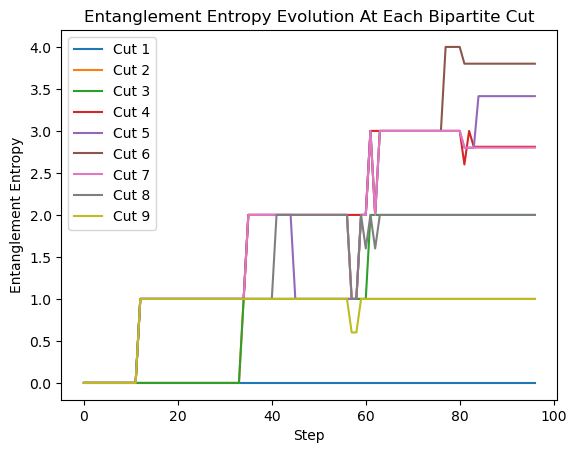

In [8]:
obfuscated_sbs = qtn.CircuitMPS(num_qubits)

entropy_list_obfuscated = [[] for _ in range(num_qubits)]

for step, gate in enumerate(c_obfuscated.gates):
    obfuscated_sbs.apply_gate(gate, cutoff=1e-10)

    psi = obfuscated_sbs.psi

    for qubit in range(1, num_qubits):
        entropy = psi.entropy(qubit)
        entropy_list_obfuscated[qubit].append(entropy)

for qubit in range(1, num_qubits):
    plt.plot(entropy_list_obfuscated[qubit], label=f'Cut {qubit}')
plt.xlabel('Step')
plt.ylabel('Entanglement Entropy')
plt.title('Entanglement Entropy Evolution At Each Bipartite Cut')
plt.legend()
plt.show()

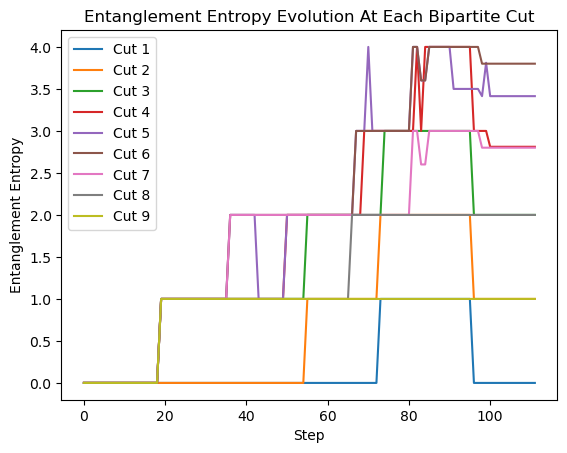

In [9]:
original_sbs = qtn.CircuitMPS(num_qubits)

entropy_list_original = [[] for _ in range(num_qubits)]

for step, gate in enumerate(c_original.gates):
    original_sbs.apply_gate(gate, cutoff=1e-10)

    psi = original_sbs.psi

    for qubit in range(1, num_qubits):
        entropy = psi.entropy(qubit)
        entropy_list_original[qubit].append(entropy)

for qubit in range(1, num_qubits):
    plt.plot(entropy_list_original[qubit], label=f'Cut {qubit}')
plt.xlabel('Step')
plt.ylabel('Entanglement Entropy')
plt.title('Entanglement Entropy Evolution At Each Bipartite Cut')
plt.legend()
plt.show()